# Anomaly Detection — Model Training

Trains an autoencoder on normal activity logs. Suspicious entries (inflated quantities,
bot-like patterns) produce high reconstruction error since the model hasn't seen them.

Threshold is the 97th percentile of reconstruction error on held-out normal data.

**Output:** `ecolums_anomaly_model.tflite` + `anomaly_config.json` → `app/src/main/assets/`

In [1]:
import subprocess, sys
PY39 = "/Library/Developer/CommandLineTools/usr/bin/python3.9"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib"])
subprocess.check_call([PY39, "-m", "pip", "install", "-q", "tensorflow", "numpy", "matplotlib"])
print("ready")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


ready


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Generate Data

Normal data uses realistic campus activity bounds. Anomalies cover three failure modes:
extreme quantities, night-time clustering, and suspiciously tiny repeated values.

In [3]:
BOUNDS = {
    **{t: (0.5, 50.0) for t in range(5)},
    5: (0.1, 20.0),
    **{t: (0.1, 8.0) for t in [6, 7, 8]},
}

def generate_normal(n, seed=0):
    np.random.seed(seed)
    rows = []
    for _ in range(n):
        t  = np.random.choice(9)
        lo, hi = BOUNDS[t]
        q  = np.clip(np.random.exponential((lo + hi) / 4), lo, hi)
        h  = int(np.clip(np.random.normal(11, 4), 6, 22))
        dw = np.random.randint(0, 7)
        mo = np.random.randint(1, 13)
        wk = 1.0 if dw >= 5 else 0.0
        rows.append([float(t), q, float(h), float(dw), float(mo), wk])
    return np.array(rows, dtype=np.float32)

def generate_anomalies(n, seed=99):
    rng  = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        kind = rng.choice(["extreme_qty", "night_cluster", "tiny_qty"])
        t    = rng.integers(0, 9)
        dw   = rng.integers(0, 7)
        mo   = rng.integers(1, 13)
        wk   = 1.0 if dw >= 5 else 0.0
        if kind == "extreme_qty":
            q, h = float(rng.uniform(200, 1000)), float(rng.integers(6, 22))
        elif kind == "night_cluster":
            q, h = float(rng.uniform(0.1, 5.0)), float(rng.integers(2, 4))
        else:
            q, h = float(rng.uniform(0.001, 0.01)), float(rng.integers(0, 24))
        rows.append([float(t), q, h, float(dw), float(mo), wk])
    return np.array(rows, dtype=np.float32)

X_normal    = generate_normal(8000)
X_anomalies = generate_anomalies(500)
split   = int(0.8 * len(X_normal))
X_train = X_normal[:split]
X_val   = X_normal[split:]

np.save("X_train.npy",     X_train)
np.save("X_val.npy",       X_val)
np.save("X_anomalies.npy", X_anomalies)
print(f"train={len(X_train)}  val={len(X_val)}  anomalies={len(X_anomalies)}")

train=6400  val=1600  anomalies=500


## Train (Python 3.9 subprocess)

In [4]:
import subprocess, os, textwrap
PY39 = "/Library/Developer/CommandLineTools/usr/bin/python3.9"
code = textwrap.dedent(r'''
import os, sys, json, shutil
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import tensorflow as tf

print(f"TF {tf.__version__}  Python {sys.version.split()[0]}")

X_train     = np.load("X_train.npy")
X_val       = np.load("X_val.npy")
X_anomalies = np.load("X_anomalies.npy")

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train)
mean = normalizer.mean.numpy().flatten().tolist()
std  = np.maximum(np.sqrt(normalizer.variance.numpy()).flatten(), 1e-7).tolist()

def normalize(X):
    return (X - np.array(mean, dtype=np.float32)) / np.array(std, dtype=np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    normalizer,
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8,  activation="relu"),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(8,  activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(6),
], name="anomaly_autoencoder")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
model.summary()

history = model.fit(
    X_train, normalize(X_train),
    validation_data=(X_val, normalize(X_val)),
    epochs=100, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)],
    verbose=1)
print(f"stopped at epoch {len(history.history['loss'])}")

fig = plt.figure(figsize=(8, 4))
ep = range(1, len(history.history["loss"]) + 1)
plt.plot(ep, history.history["loss"],     label="train", color="#3498db", linewidth=2)
plt.plot(ep, history.history["val_loss"], label="val",   color="#e67e22", linewidth=2, linestyle="--")
plt.yscale("log"); plt.title("Autoencoder Loss (MSE)"); plt.legend()
plt.tight_layout(); plt.savefig("loss.png", bbox_inches="tight"); plt.close()

def recon_error(X):
    return np.mean((normalize(X) - model.predict(X, verbose=0))**2, axis=1)

err_normal    = recon_error(X_val)
err_anomalies = recon_error(X_anomalies)
threshold     = float(np.percentile(err_normal, 97))
fpr = float(np.mean(err_normal    > threshold) * 100)
tpr = float(np.mean(err_anomalies > threshold) * 100)
print(f"threshold={threshold:.5f}  FPR={fpr:.1f}%  TPR={tpr:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.clip(err_normal,    0, threshold*5), bins=60, alpha=0.7, color="#2ecc71", label="normal",    density=True)
axes[0].hist(np.clip(err_anomalies, 0, threshold*5), bins=30, alpha=0.7, color="#e74c3c", label="anomalies", density=True)
axes[0].axvline(threshold, color="black", linewidth=2, linestyle="--", label=f"threshold={threshold:.4f}")
axes[0].set_title("Reconstruction Error"); axes[0].set_xlabel("MSE"); axes[0].legend()
n3 = len(X_anomalies) // 3
rates = [np.mean(err_anomalies[:n3]   > threshold)*100,
         np.mean(err_anomalies[n3:2*n3]> threshold)*100,
         np.mean(err_anomalies[2*n3:]  > threshold)*100]
axes[1].bar(["extreme qty","night cluster","tiny qty"], rates, color=["#e74c3c","#e67e22","#9b59b6"], edgecolor="white")
axes[1].set_ylim(0, 110); axes[1].set_title("Detection Rate by Type"); axes[1].set_ylabel("% detected")
for i, r in enumerate(rates):
    axes[1].text(i, r+2, f"{r:.0f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("evaluation.png", bbox_inches="tight"); plt.close()

ASSETS = "../../app/src/main/assets"
os.makedirs(ASSETS, exist_ok=True)

json.dump({"mean": mean, "std": std, "threshold": threshold}, open("anomaly_config.json", "w"), indent=2)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
open("ecolums_anomaly_model.tflite", "wb").write(converter.convert())
print(f"model: {os.path.getsize('ecolums_anomaly_model.tflite')/1024:.1f} KB")

for f in ["ecolums_anomaly_model.tflite", "anomaly_config.json"]:
    shutil.copy(f, os.path.join(ASSETS, f))
print(f"copied to {ASSETS}/")

json.dump({"threshold": threshold, "fpr": fpr, "tpr": tpr, "epochs": len(history.history["loss"])},
          open("metrics.json", "w"))

interp = tf.lite.Interpreter(model_path="ecolums_anomaly_model.tflite")
interp.allocate_tensors()
inp = interp.get_input_details()[0]["index"]
out = interp.get_output_details()[0]["index"]
mean_a, std_a = np.array(mean), np.array(std)
cases = [
    ("bike  5km  8am  (normal)",       [1, 5.0,   8, 1, 4, 0]),
    ("bus   12km 5pm  (normal)",       [0, 12.0, 17, 2, 9, 0]),
    ("bike  500km     (anomaly)",      [1, 500.0, 9, 0, 3, 0]),
    ("energy 0.001kWh 3am (anomaly)",  [5, 0.001, 3, 1, 5, 0]),
    ("car   30km  2am (anomaly)",      [2, 30.0,  2, 3, 7, 0]),
]
print(f"\n{'case':<38} {'score':>8}  flag")
print("-" * 54)
for label, feat in cases:
    x = np.array([feat], dtype=np.float32)
    normed = (x - mean_a) / std_a
    interp.set_tensor(inp, x); interp.invoke()
    score = float(np.mean((normed - interp.get_tensor(out))**2))
    print(f"{label:<38} {score:>8.5f}  {'YES' if score > threshold else 'no'}")
print(f"\nthreshold: {threshold:.5f}")
''')
result = subprocess.run([PY39, "-c", code], capture_output=True, text=True, cwd=os.path.abspath("."))
print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)

TF 2.19.0  Python 3.9.6
Model: "anomaly_autoencoder"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 6)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├──────────────────────

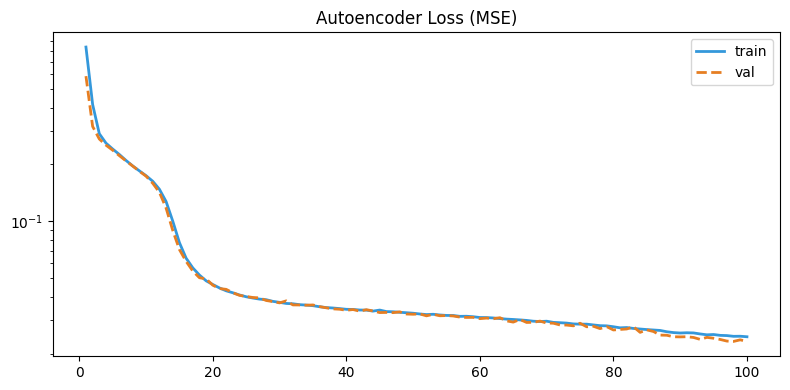

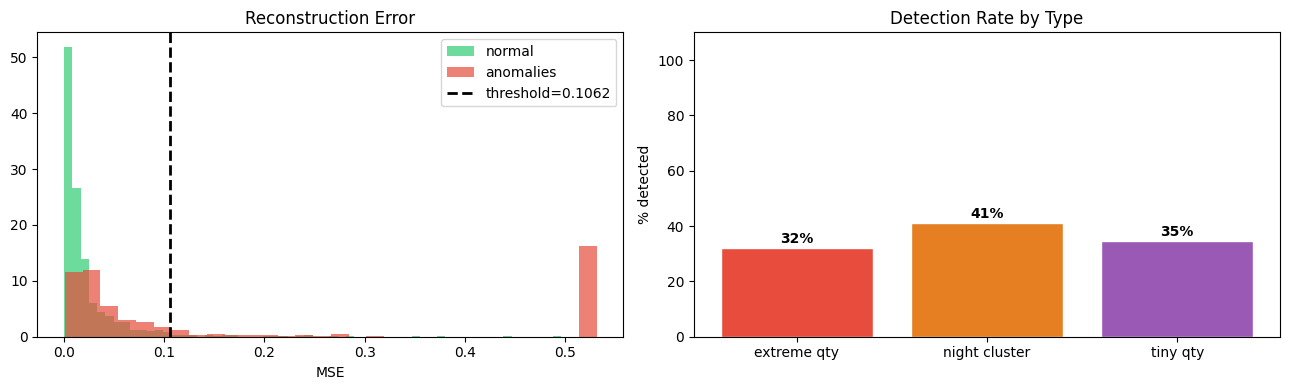

threshold=0.10624  FPR=3.0%  TPR=35.8%  epochs=100


In [5]:
from IPython.display import Image, display
import json, os
for img in ["loss.png", "evaluation.png"]:
    if os.path.exists(img): display(Image(img))
if os.path.exists("metrics.json"):
    m = json.load(open("metrics.json"))
    print(f"threshold={m['threshold']:.5f}  FPR={m['fpr']:.1f}%  TPR={m['tpr']:.1f}%  epochs={m['epochs']}")